In [1]:
import os, shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dabest
import osar
import warnings
warnings.filterwarnings("ignore")

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 49.09it/s]

Numba compilation complete!


In [2]:
basegenotype = "SS01188"
dir1 = "C:\\Users\\User\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\OSAR\\SS01188 x Chrimson2"
dir2 = "C:\\Users\\User\\Downloads\\SS01188 x Chrimson2\\SS01188 x Chrimson2"

In [3]:
a1 = osar.osar(dir1, driver=basegenotype)
r1 = a1.results.copy()

Creating borders for each fly...
Done.

Processing CSV 36 of 36
Summarising results for all flies...
All done.


In [4]:
full_red = os.path.join(dir2, "Full_Red")
for f in os.listdir(full_red):
    if f.startswith("CountLog_") and f.endswith(".csv") and f.count("_") == 2:
        os.rename(os.path.join(full_red, f),
                  os.path.join(full_red, f.replace(".csv", "_SS01188 x Chrimson2_Full_Red.csv")))

borders_dst = os.path.join(dir2, "borders")
if not os.path.exists(borders_dst):
    shutil.copytree(os.path.join(dir1, "borders"), borders_dst)

In [ ]:
a2 = osar.osar(dir2, driver=basegenotype, countlog_folder="Full_Red")
r2 = a2.results.copy()

In [ ]:
df = pd.concat([r1, r2], ignore_index=True)
df = df[(df['status'] == 'Offspring') & (df['light_intensity'] == 'Full')].copy()
df = df[['exptDate', 'pi_smoothed_Pattern 01']].dropna()
df['exptDate'] = df['exptDate'].astype(str)
dates = sorted(df['exptDate'].unique())
dates

In [ ]:
test = dabest.load(df, idx=tuple(dates), x='exptDate', y='pi_smoothed_Pattern 01')
test.hedges_g.plot(float_contrast=False, fontsize_rawylabel=10, fontsize_rawxlabel=9,
                   fontsize_contrastxlabel=9, fontsize_contrastylabel=10,
                   raw_marker_size=2, contrast_marker_size=6,
                   custom_palette="Paired", raw_label="PI (Pattern 01)",
                   contrast_ylim=(-1.5, 1.5), contrast_label="Hedges' g");

## SS67741 x ACR (Full Green)
Dates: 2024-07-09 (dropbox) + 2026-04-16 (Downloads)

In [9]:
basegenotype2 = "SS67741"
dir3 = "C:\\Users\\User\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\OSAR\\SS67741 x ACR"
dir4 = "C:\\Users\\User\\Downloads\\SS67741 x ACR"

In [10]:
b1 = osar.osar(dir3, driver=basegenotype2)
s1 = b1.results.copy()

Creating borders for each fly...
Done.

Processing CSV 50 of 50
Summarising results for all flies...
All done.


In [11]:
full_green = os.path.join(dir4, "Full Green")
for f in os.listdir(full_green):
    if f.startswith("CountLog_") and f.endswith(".csv") and f.count("_") == 2:
        os.rename(os.path.join(full_green, f),
                  os.path.join(full_green, f.replace(".csv", "_SS67741 x ACR_Full_Green.csv")))

borders_dst2 = os.path.join(dir4, "borders")
if not os.path.exists(borders_dst2):
    shutil.copytree(os.path.join(dir3, "borders"), borders_dst2)

In [12]:
b2 = osar.osar(dir4, driver=basegenotype2, countlog_folder="Full Green")
s2 = b2.results.copy()

Creating borders for each fly...
Done.

Processing CSV 12 of 12
Summarising results for all flies...
All done.


In [13]:
df2 = pd.concat([s1, s2], ignore_index=True)
df2 = df2[(df2['status'] == 'Offspring') & (df2['light_intensity'] == 'Full')].copy()
df2 = df2[['exptDate', 'pi_smoothed_Pattern 01']].dropna()
df2['exptDate'] = df2['exptDate'].astype(str)
dates2 = sorted(df2['exptDate'].unique())
dates2

['2024-07-09', '2026-04-16']

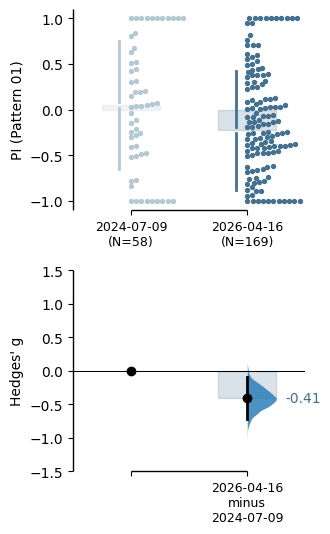

In [14]:
test2 = dabest.load(df2, idx=tuple(dates2), x='exptDate', y='pi_smoothed_Pattern 01')
test2.hedges_g.plot(float_contrast=False, fontsize_rawylabel=10, fontsize_rawxlabel=9,
                    fontsize_contrastxlabel=9, fontsize_contrastylabel=10,
                    raw_marker_size=2, contrast_marker_size=6,
                    custom_palette="Paired", raw_label="PI (Pattern 01)",
                    contrast_ylim=(-1.5, 1.5), contrast_label="Hedges' g");